# 01 — Data Exploration
Explore the FOLIO dataset: loading, preprocessing, token length distribution, label distribution.

In [7]:
# ── Colab setup (skip if running locally) ──────────────────────────────────
import os
IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Update this path if your outputs folder is elsewhere
    OUTPUT_DIR = '/content/drive/MyDrive/slm_logic_hardening/outputs'
    !pip install -q transformers datasets pyyaml sentencepiece
    # Navigate directly to your existing project folder in Drive
    %cd '/content/drive/MyDrive/slm_logic_hardening'
else:
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path().resolve()))
    OUTPUT_DIR = 'outputs'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/slm_logic_hardening


In [ ]:
!pip install -q huggingface_hub

In [13]:
from huggingface_hub import login
# This will prompt you for your Hugging Face token
login()

In [14]:
import torch
device = 'mps' if torch.backends.mps.is_available() else \
         'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


## 1. Load raw FOLIO dataset

In [15]:
from data.load_data import load_folio

dataset = load_folio()
print(dataset)
print(f'\nTrain: {len(dataset["train"])} | Validation: {len(dataset["validation"])}')

folio_v2_train.jsonl: 0.00B [00:00, ?B/s]

folio_v2_validation.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1001 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/203 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['story_id', 'premises', 'premises-FOL', 'conclusion', 'conclusion-FOL', 'label', 'example_id'],
        num_rows: 1001
    })
    validation: Dataset({
        features: ['story_id', 'premises', 'premises-FOL', 'conclusion', 'conclusion-FOL', 'label', 'example_id'],
        num_rows: 203
    })
})

Train: 1001 | Validation: 203


In [16]:
# Inspect one raw example
example = dataset['train'][0]
for k, v in example.items():
    print(f'{k}: {v}')

story_id: 406
premises: All people who regularly drink coffee are dependent on caffeine.
People regularly drink coffee, or they don't want to be addicted to caffeine, or both.
No one who doesn't want to be addicted to caffeine is unaware that caffeine is a drug.
Rina is either a student who is unaware that caffeine is a drug, or she is not a student and is she aware that caffeine is a drug.
Rina  is either a student who is dependent on caffeine, or she is not a student and not dependent on caffeine.
premises-FOL: ∀x (DrinkRegularly(x, coffee) → IsDependentOn(x, caffeine))
∀x (DrinkRegularly(x, coffee)  ∨ (¬WantToBeAddictedTo(x, caffeine)))
∀x (¬WantToBeAddictedTo(x, caffeine) → ¬AwareThatDrug(x, caffeine))
¬(Student(rina) ⊕  ¬AwareThatDrug(rina, caffeine))
¬(IsDependentOn(rina, caffeine) ⊕ Student(rina))
conclusion: Rina doesn't want to be addicted to caffeine or is unaware that caffeine is a drug.
conclusion-FOL: ¬WantToBeAddictedTo(rina, caffeine) ∨ (¬AwareThatDrug(rina, caffeine))
l

## 2. Preprocess and inspect formatted prompt

In [17]:
from data.preprocess import preprocess_folio

processed = preprocess_folio(dataset)
sample = processed['train'][0]

print('=== PROMPT ===')
print(sample['prompt'])
print('\n=== TARGET ===')
print(sample['target_text'])
print(f'\nLabel: {sample["label"]} | Premises: {sample["no_of_premises"]}')

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/203 [00:00<?, ? examples/s]

=== PROMPT ===
You are a Logical Reasoning System.

Premises:
All people who regularly drink coffee are dependent on caffeine.
People regularly drink coffee, or they don't want to be addicted to caffeine, or both.
No one who doesn't want to be addicted to caffeine is unaware that caffeine is a drug.
Rina is either a student who is unaware that caffeine is a drug, or she is not a student and is she aware that caffeine is a drug.
Rina  is either a student who is dependent on caffeine, or she is not a student and not dependent on caffeine.

Hypothesis:
Rina doesn't want to be addicted to caffeine or is unaware that caffeine is a drug.

Question:
Is the hypothesis True, False, or Uncertain?

Answer:


=== TARGET ===
True

Label: true | Premises: 5


## 3. Token length distribution

In [18]:
from transformers import AutoTokenizer
from statistics import mean

tokenizer = AutoTokenizer.from_pretrained('microsoft/Phi-3.5-mini-instruct')

def token_length(text):
    return len(tokenizer(text, truncation=False, padding=False)['input_ids'])

prompt_lengths = [token_length(r['prompt']) for r in processed['train']]
full_lengths = [token_length(r['full_text']) for r in processed['train']]

print(f'Prompt  — min: {min(prompt_lengths)} | avg: {mean(prompt_lengths):.1f} | max: {max(prompt_lengths)}')
print(f'Full    — min: {min(full_lengths)}  | avg: {mean(full_lengths):.1f}  | max: {max(full_lengths)}')
print(f'Examples > 384 tokens: {sum(l > 384 for l in full_lengths)}')

config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Prompt  — min: 63 | avg: 151.5 | max: 366
Full    — min: 65  | avg: 152.8  | max: 367
Examples > 384 tokens: 0


## 4. Label distribution

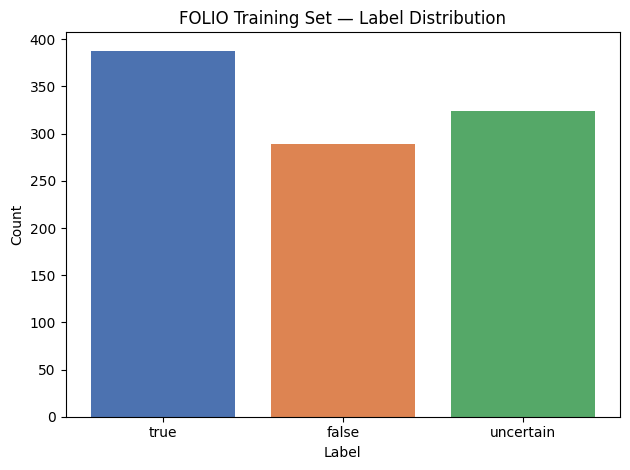

Counter({'true': 388, 'uncertain': 324, 'false': 289})


In [19]:
from collections import Counter
import matplotlib.pyplot as plt

label_counts = Counter(r['label'] for r in processed['train'])
labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.bar(labels, counts, color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('FOLIO Training Set — Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/label_distribution.png', dpi=150)
plt.show()
print(label_counts)

## 5. Premise count distribution

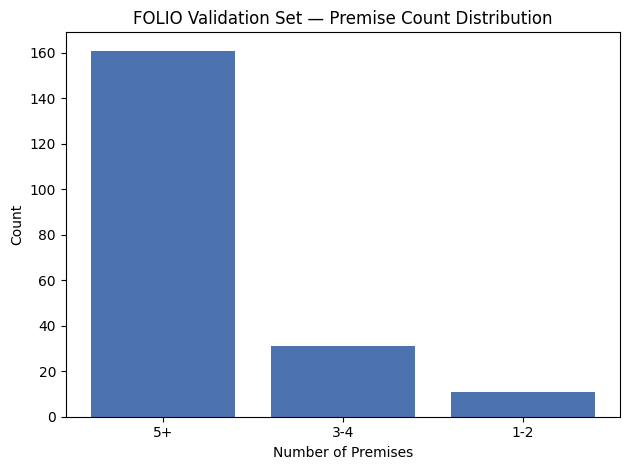

Counter({'5+': 161, '3-4': 31, '1-2': 11})


In [20]:
premise_counts = [r['no_of_premises'] for r in processed['validation']]
bin_counts = Counter(
    '1-2' if c <= 2 else '3-4' if c <= 4 else '5+'
    for c in premise_counts
)

plt.bar(list(bin_counts.keys()), list(bin_counts.values()), color='#4C72B0')
plt.title('FOLIO Validation Set — Premise Count Distribution')
plt.xlabel('Number of Premises')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(bin_counts)

```markdown
### 6. Move Notebook to Project Directory
Run the cell below to move this notebook from its current location to your project's `notebooks` folder.
```

In [ ]:
```python
import shutil
import os

# Define source and destination
# Assuming this notebook is currently in 'Colab Notebooks'
current_path = '/content/drive/MyDrive/Colab Notebooks/01_data_exploration.ipynb'
dest_folder = '/content/drive/MyDrive/slm_logic_hardening/notebooks'
dest_path = os.path.join(dest_folder, '01_data_exploration.ipynb')

if not os.path.exists(dest_folder):
    os.makedirs(dest_folder)
    print(f"Created directory: {dest_folder}")

try:
    shutil.copy(current_path, dest_path)
    print(f"Successfully copied notebook to: {dest_path}")
    print("You can now open the version inside the 'slm_logic_hardening/notebooks' folder!")
except FileNotFoundError:
    print(f"Could not find the notebook at {current_path}. Please check the filename.")
```